In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import numpy as np

# 设置绘图风格和中文字体
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 导入数据,涵盖orders,customers,order_itmes,sellers等四张表的基本信息
con = sqlite3.connect('olist.db')

sql_query = """
    SELECT 
        -- 1、订单基本信息
        o.order_id,
        o.order_status,
        o.order_purchase_timestamp,

        -- 2、买家信息
        c.customer_unique_id,
        c.customer_state,
        c.customer_city,

        -- 3、商品和交易信息
        oi.product_id,
        oi.price,
        oi.freight_value,

        -- 4、卖家信息
        s.seller_id,
        s.seller_city,
        s.seller_state,

        -- 5、产品种类
        ca.product_category_name_english

FROM orders o
INNER JOIN customers c ON o.customer_id = c.customer_id
INNER JOIN order_items oi on o.order_id = oi.order_id
INNER JOIN sellers s ON oi.seller_id = s.seller_id
LEFT JOIN products p ON oi.product_id = p.product_id -- 防止部分商品因null而被删除
LEFT JOIN category_translation ca ON p.product_category_name = ca.product_category_name
WHERE o.order_status = 'delivered';

"""

# 读取和检查数据
df_four = pd.read_sql_query(sql_query, con)
df_four.info()
df_four.head()

# 共110197条数据，没有缺失值

<class 'pandas.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       110197 non-null  str    
 1   order_status                   110197 non-null  str    
 2   order_purchase_timestamp       110197 non-null  str    
 3   customer_unique_id             110197 non-null  str    
 4   customer_state                 110197 non-null  str    
 5   customer_city                  110197 non-null  str    
 6   product_id                     110197 non-null  str    
 7   price                          110197 non-null  float64
 8   freight_value                  110197 non-null  float64
 9   seller_id                      110197 non-null  str    
 10  seller_city                    110197 non-null  str    
 11  seller_state                   110197 non-null  str    
 12  product_category_name_english  108638 non

,order_id,order_status,order_purchase_timestamp,customer_unique_id,customer_state,customer_city,product_id,price,freight_value,seller_id,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,87285b34884572647811a353c7ac498a,29.99,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,maua,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,BA,barreiras,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,289cdb325fb7e7f891c38608bf9e0962,belo horizonte,SP,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,aa4383b373c6aca5d8797843e5594415,159.90,19.22,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,RN,sao goncalo do amarante,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,66922902710d126a0e7d26b0e3805106,belo horizonte,MG,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,SP,santo andre,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,2c9e548be18521d1c43cde1c582c6de8,mogi das cruzes,SP,stationery


In [3]:
# 处理重复值
df_four.duplicated().sum()
df_four.drop_duplicates(inplace=True)

In [4]:
# 描述性统计
df_four.describe()

# 平均价为123，但中位数却只有78，说明存在存在大量高价订单拉高了平均价，符合常规的电商行业情况
# 各数值基本正常

,price,freight_value
count,100196.000000,100196.000000
mean,123.751681,20.069096
std,187.654634,15.780795
min,0.850000,0.000000
25%,40.000000,13.140000
50%,78.000000,16.320000
75%,139.000000,21.190000
max,6735.000000,409.680000


In [5]:
# 转换时间格式
df_four['order_purchase_timestamp'] = pd.to_datetime(df_four['order_purchase_timestamp'], errors='coerce')

In [6]:
# 处理业务噪音
df_four = df_four[df_four['order_purchase_timestamp'].dt.year != 2016].reset_index()

# 由于2016年平台还处于试营阶段，订单量较少，为保证分析的准确性，将2016年的数据删掉

In [7]:
# =========== 维度一：核心指标大盘 ===================

# 总GMV
total_sale = df_four['price'].sum()
print(f'总GMV:{total_sale:.2f}')

# 总订单量
total_orders= df_four['order_id'].count()
print(f'总订单量:{total_orders:.2f}')

# 人流量
total_customer = df_four['customer_unique_id'].nunique()
print(f'人流量:{total_customer}')

# 活跃商家数(有卖过的东西的商家)
total_seller = df_four['seller_id'].nunique()
print(f'活跃商家数:{total_seller}')

# 客单价
avg_price = total_sale / total_orders
print(f'客单价:{avg_price:.2f}')

# 总订单量与人流量十分接近，说明回头客非常少，接下来可以进行用户分层，进一步探究平台的用户结构，以便后续业务进行针对性调整

总GMV:12361900.18
总订单量:99915.00
人流量:93104
活跃商家数:2945
客单价:123.72


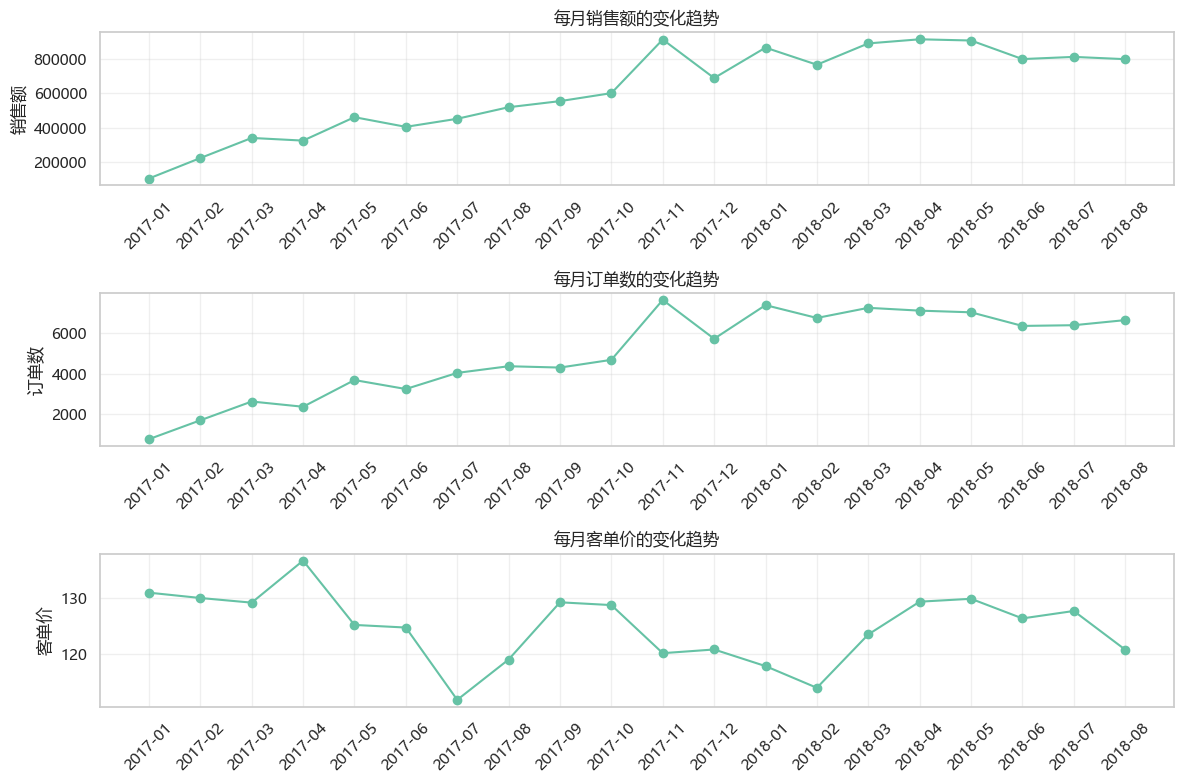

In [8]:
# ==================== 维度二：时间趋势分析 =====================

# 统计每月的GMV、订单数和客单价
monthly_gmv = df_four.groupby(df_four['order_purchase_timestamp'].dt.to_period('M'))['price'].sum()
monthly_orders = df_four.groupby(df_four['order_purchase_timestamp'].dt.to_period('M'))['order_id'].count()

monthly_data = df_four.groupby(df_four['order_purchase_timestamp'].dt.to_period('M')).agg(总销售额 = ('price','sum'),
                                                                                               总订单数 = ('order_id','count'))
monthly_avg_price = round(monthly_data['总销售额'] / monthly_data['总订单数'], 2)

# 绘制折线图

plt.figure(figsize=(12, 8)) # 绘制画布
x_label = monthly_gmv.index.astype(str) # 将月份转成字符串形式，强制在x轴上表现出来
sns.set_palette('Set2') # 自动添加颜色

# GMV
plt.subplot(3,1,1)
plt.plot(x_label, monthly_gmv.values, marker='o')
plt.ylabel('销售额')
plt.title('每月销售额的变化趋势')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

# 订单数
plt.subplot(3,1,2)
plt.plot(x_label, monthly_orders.values, marker='o')
plt.ylabel('订单数')
plt.title('每月订单数的变化趋势')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

# 客单价
plt.subplot(3,1,3)
plt.plot(x_label, monthly_avg_price.values, marker='o')
plt.ylabel('客单价')
plt.title('每月客单价的变化趋势')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 每月销售额的变化趋势和订单数的变化趋势几乎完全一致，整体上呈现出递增的趋势，两者都在2017-11达到峰值，可见黑色星期五购物节带来了很大的影响
# 客单价的变化趋势相较两者存在一定的波动，大部分都落于120-130的区间内，分别在2017-07和2018-02出现了两次低谷
# 针对销售额和订单数的不断递增，以及客单价长期处于较高状态，这与巴西人的工资水平不符，接下来可进一步探究用户的支付行为，以便增加对用户情况的了解

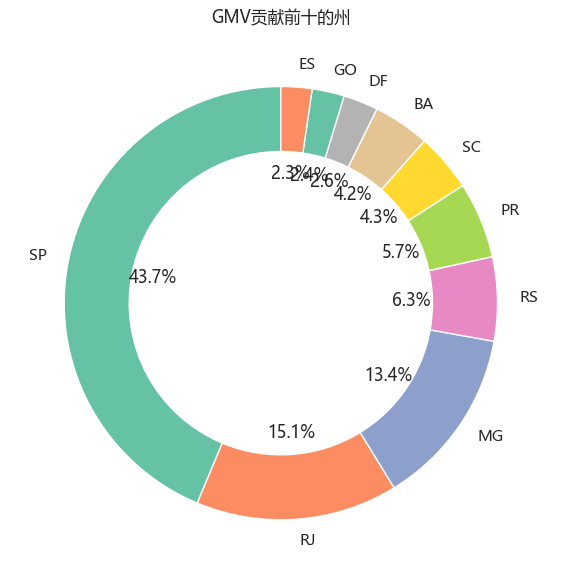

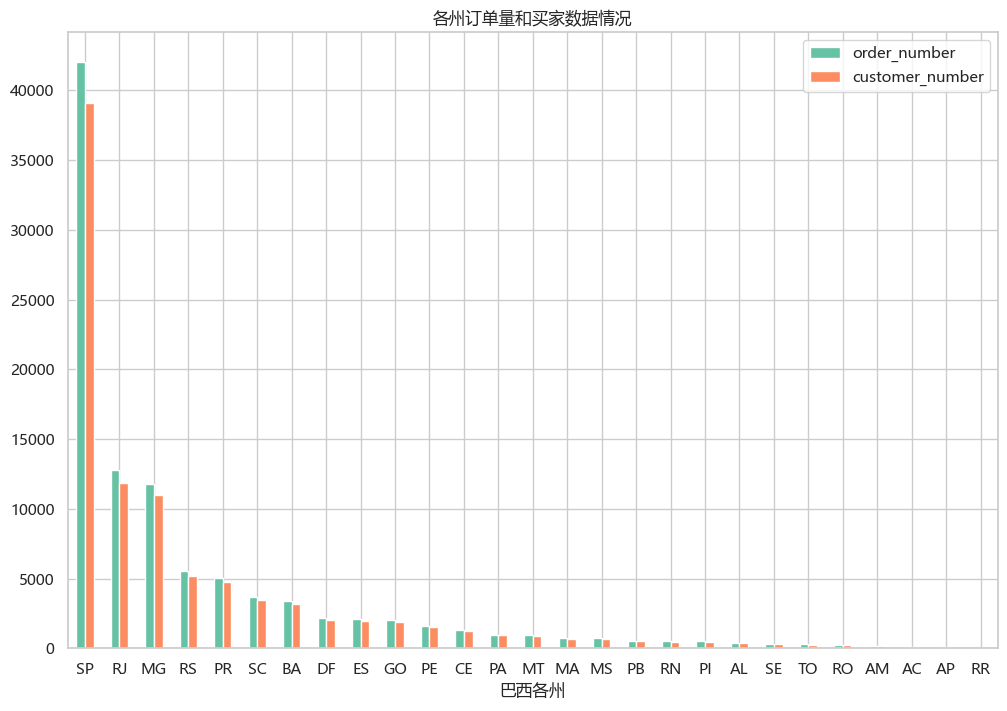

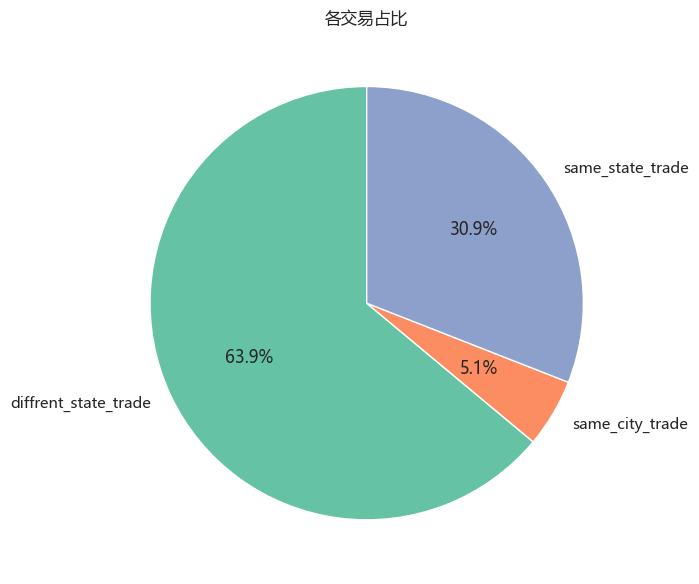

In [9]:
# ========================== 维度三：地域分布分析 ==========================

# GMV贡献占比前十的州
state_gmv = df_four.groupby('customer_state')['price'].sum().sort_values(ascending=False).head(10)

# 各州订单量和买家
state_order_customer = df_four.groupby('customer_state').agg(
                            order_number=('order_id', 'count'),
                            customer_number=('customer_unique_id', 'nunique')).reset_index().sort_values(by= 'order_number', ascending=False)

# 不同类型的交易的占比

# 定义新列
condition = [
    (df_four['customer_state'] == df_four['seller_state']) & (df_four['customer_city'] == df_four['seller_city']), # 同城交易
    (df_four['customer_state'] == df_four['seller_state']) & (df_four['customer_city'] != df_four['seller_city']), # 同州交易
    (df_four['customer_state'] != df_four['seller_state']), # 跨州交易
            ]

colums = ['same_city_trade','same_state_trade','diffrent_state_trade']

df_four['trade_type'] = np.select(condition, colums,default='other')

# 统计各类型交易的订单数占比
trade_type_percent = df_four.groupby('trade_type')['order_id'].count().reset_index()
trade_type_percent.columns = ['trade','order_sum']
trade_type_percent['proportion'] = trade_type_percent['order_sum'] / trade_type_percent['order_sum'].sum()

# ========= 可视化 ==========

sns.set_palette('Set2') 

# GMV
plt.figure(figsize=(8,6))
state_gmv.plot.pie(wedgeprops={'width':0.3},autopct='%1.1f%%',startangle=90)
plt.title('GMV贡献前十的州')
plt.tight_layout()
plt.show()


# 各州订单量和买家
plt.figure(figsize=(12,8))
state_order_customer.set_index('customer_state')[['order_number','customer_number']].plot.bar(ax=plt.gca())
plt.xlabel('巴西各州')
plt.legend()
plt.title('各州订单量和买家数据情况')
plt.xticks(rotation=0)
plt.show()

# 不同类型的交易
plt.figure(figsize=(8,6))
trade_type_percent.set_index('trade')['proportion'].plot.pie(autopct='%1.1f%%',startangle=90)
plt.title('各交易占比')
plt.tight_layout()
plt.show()

# 由图可知，sp州占据了近半的GMV，而且在订单数和人流量上也远高于其他州，其中各州的经济因素是占主导作用的，因此应该倾向于向经济比较发达的几个州倾斜资源
# 在所有交易中，跨州交易占据了60%以上，考虑到巴西幅员辽阔，可以进一步分析运费因素的影响

C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_16632\1425811386.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gmv', y='product_category_name_english', data=top10_gmv, palette='Blues_r')
C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_16632\1425811386.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='orders', y='product_category_name_english', data=top10_orders, palette='Greens_r')


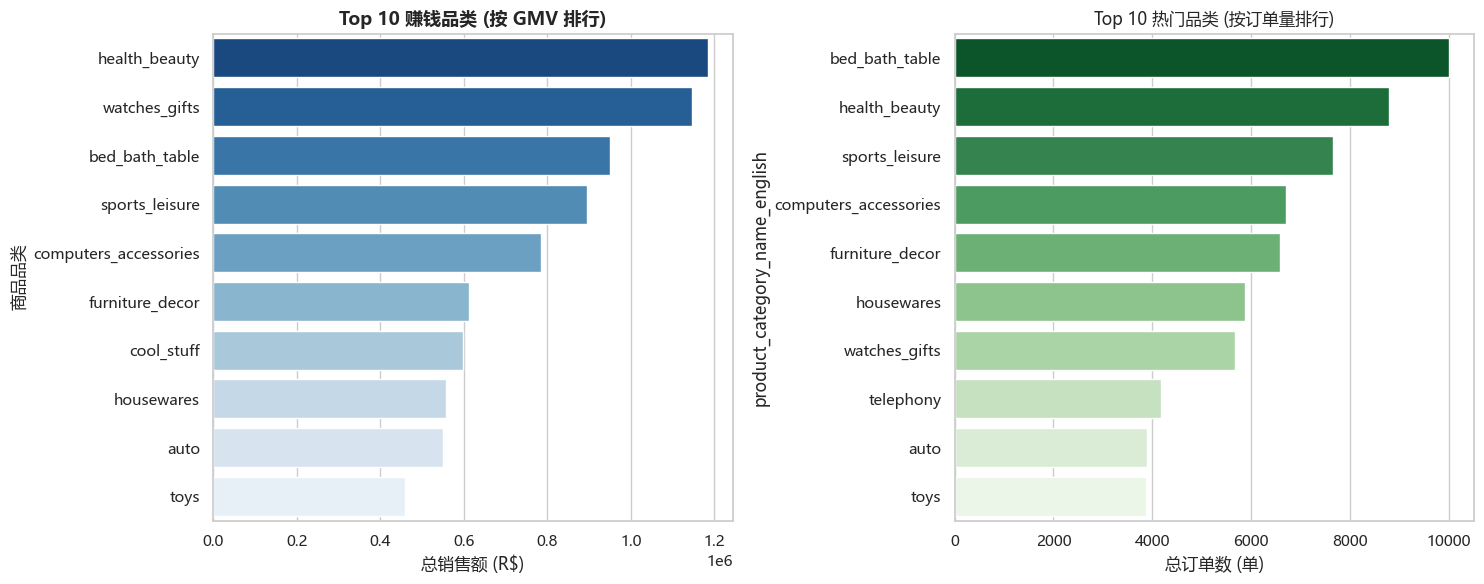

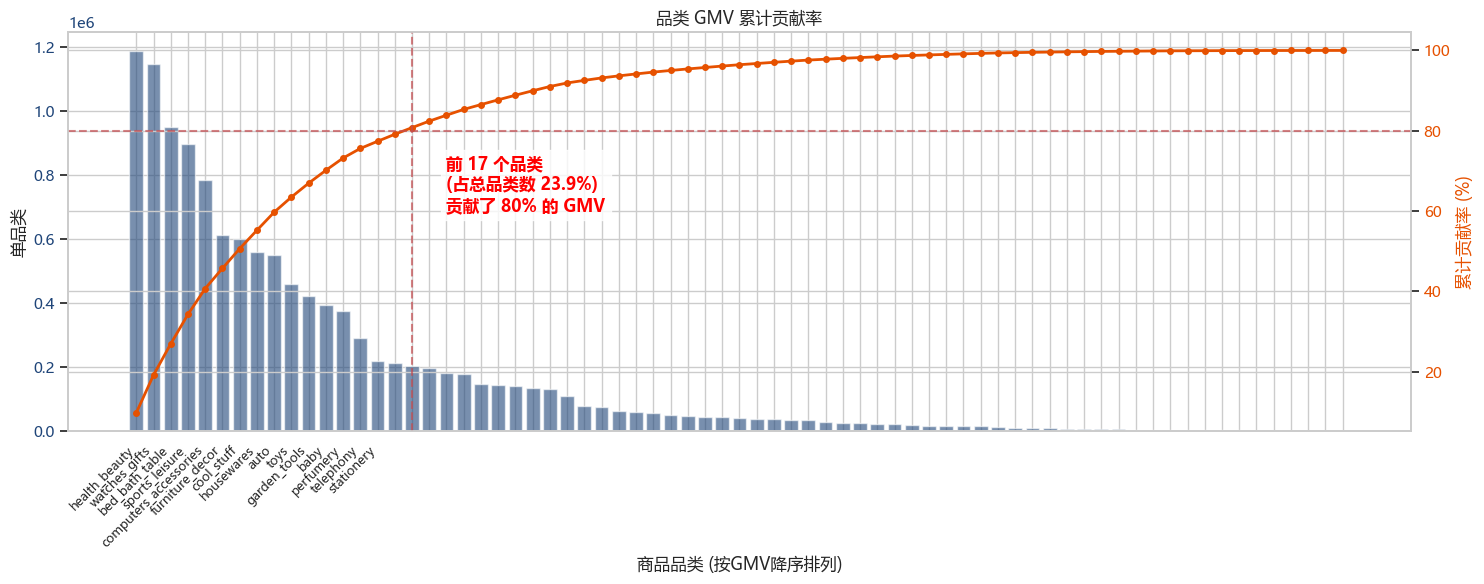

In [10]:
# ============================ 维度四：商品品类 ====================

# 按品类聚合计算 GMV、订单量、平均价格、平均运费
cat_summary = df_four.groupby('product_category_name_english').agg(
    gmv=('price', 'sum'),
    orders=('order_id', 'count'),
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean')
).reset_index()

# 可视化
plt.figure(figsize=(15, 6))

# 赚钱品类：按 GMV 排行前 10
plt.subplot(1, 2, 1)
top10_gmv = cat_summary.sort_values(by='gmv', ascending=False).head(10)
sns.barplot(x='gmv', y='product_category_name_english', data=top10_gmv, palette='Blues_r')
plt.title('Top 10 赚钱品类 (按 GMV 排行)', fontsize=13, fontweight='bold')
plt.xlabel('总销售额 (R$)')
plt.ylabel('商品品类')

# 热门品类：按订单量排行前 10
plt.subplot(1, 2, 2)
top10_orders = cat_summary.sort_values(by='orders', ascending=False).head(10)
sns.barplot(x='orders', y='product_category_name_english', data=top10_orders, palette='Greens_r')
plt.title('Top 10 热门品类 (按订单量排行)')
plt.xlabel('总订单数 (单)')

plt.tight_layout()
plt.show()

# =================== 品类 GMV 帕累托图 ======================

# 按照 GMV 降序排列
pareto_data = cat_summary.sort_values(by='gmv', ascending=False).reset_index(drop=True)

# 计算累计百分比
pareto_data['cum_percentage'] = 100 * pareto_data['gmv'].cumsum() / pareto_data['gmv'].sum()

fig, ax1 = plt.subplots(figsize=(15, 6))

# 1. 画柱状图 (左轴：各品类 GMV)
color = "#1f4579"
ax1.set_title('品类 GMV 累计贡献率')
ax1.set_xlabel('商品品类 (按GMV降序排列)')
ax1.set_ylabel('单品类')

ax1.bar(pareto_data.index, pareto_data['gmv'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(range(len(pareto_data)), 
           [name if i < 15 else '' for i, name in enumerate(pareto_data['product_category_name_english'])], 
           rotation=45, ha='right', fontsize=9)

# 2. 画折线图 (右轴：累计百分比)
ax2 = ax1.twinx()  # 共享 X 轴，创建双 Y 轴
color = '#e65100'
ax2.set_ylabel('累计贡献率 (%)', color=color, fontsize=12)
ax2.plot(pareto_data.index, pareto_data['cum_percentage'], color=color, marker='o', ms=4, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

# 3. 绘制 80% 黄金分割线
ax2.axhline(y=80, color='r', linestyle='--', alpha=0.7, label='80% 贡献线')
# 找到累计达到 80% 时的品类位置
cutoff_idx = pareto_data[pareto_data['cum_percentage'] >= 80].index[0]
ax2.axvline(x=cutoff_idx, color='r', linestyle='--', alpha=0.7)

# 标注二八定律结论
total_categories = len(pareto_data)
pct_categories = (cutoff_idx + 1) / total_categories * 100
plt.text(cutoff_idx + 2, 60, f"前 {cutoff_idx+1} 个品类\n(占总品类数 {pct_categories:.1f}%)\n贡献了 80% 的 GMV", 
         color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# 美妆、手表礼品等17个品类是平台的核心商品，贡献了80%的销售额，是平台需要着重发展的对象
# 接下来可以进一步了解核心商品背后的卖家竞争格局，形成平台、商品、商家的三方意识，为以后的核心产品扶持政策提供方位

In [11]:
# =============================== 维度五：订单健康情况 ==============================

# -------------- 读取和清洗数据 -----------------

# 读取完整的orders表
sql_query =""" 
SELECT order_id,
       customer_id,
       order_status,
       order_purchase_timestamp,
       order_approved_at,
       order_delivered_carrier_date,
       order_delivered_customer_date,
       order_estimated_delivery_date
FROM orders
"""
df_one = pd.read_sql_query(sql_query,con)

# 处理重复值
df_one.drop_duplicates(inplace=True)

# 转换时间格式
times_col = ['order_purchase_timestamp',
             'order_approved_at',
             'order_delivered_carrier_date',
             'order_delivered_customer_date',
             'order_estimated_delivery_date']
df_one[times_col] = df_one[times_col].apply(pd.to_datetime)

# 处理业务噪音
df_one = df_one[df_one['order_purchase_timestamp'].dt.year != 2016].reset_index()


C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_16632\2968703355.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


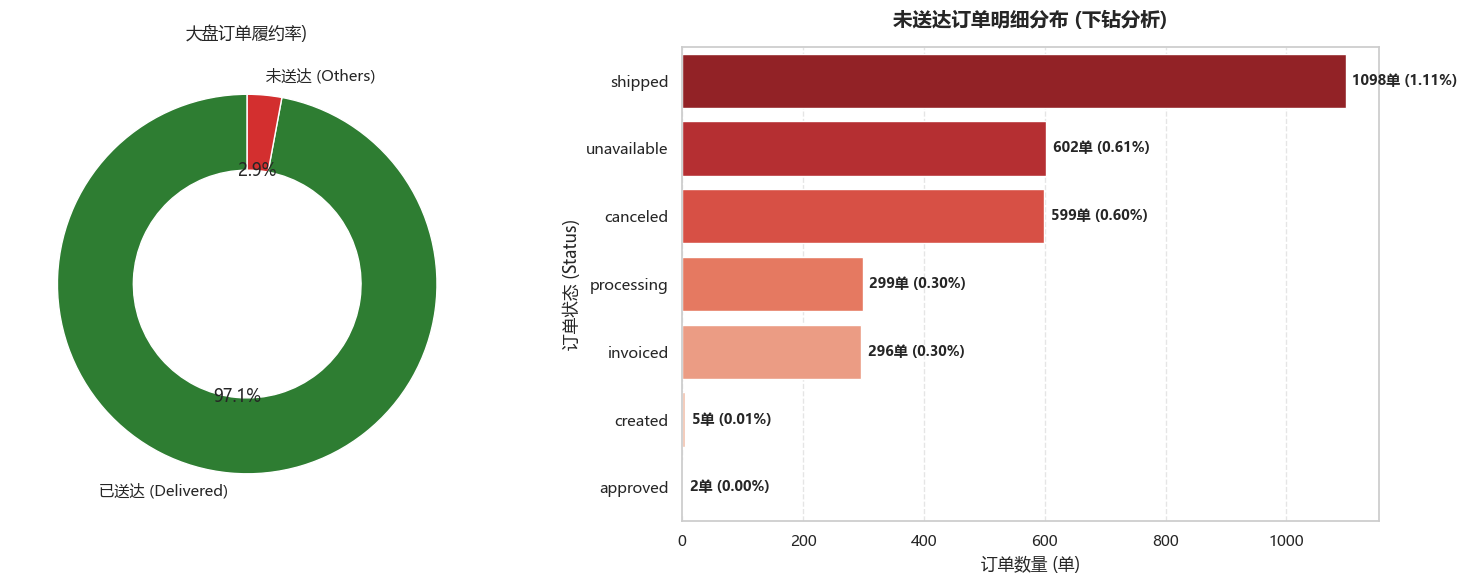

In [ ]:
# ----------------- 数据分析 --------------------

# 1. 计算各状态的数量
status_counts = df_one['order_status'].value_counts().reset_index()
status_counts.columns = ['order_status', 'count']
status_counts['percentage'] = status_counts['count'] / status_counts['count'].sum()

# 2. 将数据分为 "已送达" 和 "非已送达" 两大类
delivered_count = status_counts[status_counts['order_status'] == 'delivered']['count'].sum()
others_count = status_counts[status_counts['order_status'] != 'delivered']['count'].sum()

macro_data = pd.DataFrame({
    'category': ['已送达 (Delivered)', '未送达 (Others)'],
    'count': [delivered_count, others_count]
})

# 3. 过滤出“未送达”的明细数据（排除 delivered）
non_delivered_details = status_counts[status_counts['order_status'] != 'delivered'].copy()

# ======== 开始画图 ========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.set_palette('Pastel1')

# ---- 左图：大盘履约率（圆环图） ----
ax1.pie(
    macro_data['count'], 
    labels=macro_data['category'],
    autopct='%1.1f%%', 
    startangle=90,
    colors=['#2e7d32', '#d32f2f'], 
    wedgeprops=dict(width=0.4, edgecolor='w') 
)
ax1.set_title('大盘订单履约率)')

# ---- 右图：未送达订单明细下钻（水平条形图） ----
# 按照数量从大到小排序
non_delivered_details = non_delivered_details.sort_values(by='count', ascending=False)

sns.barplot(
    x='count', 
    y='order_status', 
    data=non_delivered_details, 
    ax=ax2, 
    palette='Reds_r' 
)

# 在条形图右侧显示具体数量和占比
for i, row in enumerate(non_delivered_details.itertuples()):
    ax2.text(
        row.count + (non_delivered_details['count'].max() * 0.01), 
        i, 
        f"{row.count}单 ({row.percentage:.2%})", 
        va='center', 
        fontsize=10, 
        fontweight='bold'
    )

ax2.set_title('未送达订单明细分布 (下钻分析)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('订单数量 (单)')
ax2.set_ylabel('订单状态 (Status)')
ax2.grid(axis='x', linestyle='--', alpha=0.5)

# 调整布局
plt.tight_layout()
plt.show()

# 平台整体履约率达97%，运行状态较为健康
# 未履约的订单虽然只占3%，但是其中超过三分之一都是在途中(shipped),说明有大量订单卡在了运输途中
# 由此可以看出物流运输存在一定问题，接下来可进一步分析物流情况

In [13]:
# ============================ 深入探究：用户分层及相关探究 =========================

# ------------------- 数据读取与清洗 ---------------------------

# 读取数据
sql_query = """ 
SELECT c.customer_unique_id,
       MAX(o.order_purchase_timestamp) AS last_purchase_time,
       COUNT(DISTINCT o.order_id) AS frequency,
       SUM(oi.price) AS monetary
FROM orders o
INNER JOIN customers c ON o.customer_id = c.customer_id
INNER JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
"""

df_rfm_raw = pd.read_sql_query(sql_query, con)

# 处理重复值
df_rfm_raw.drop_duplicates(inplace=True)

# 转换时间格式
df_rfm_raw['last_purchase_time'] = pd.to_datetime(df_rfm_raw['last_purchase_time'])

# 处理业务噪音
dp_one = df_rfm_raw[df_rfm_raw['last_purchase_time'] != 2016]

In [14]:
# ----------------------- 用户分层 -------------------------------

# 以数据集中最后一笔订单的时间 + 1天 作为“今天”（分析基准点）
today = df_rfm_raw['last_purchase_time'].max() + pd.Timedelta(days=1)

# 计算 Recency (距离今天的天数)
df_rfm_raw['recency'] = (today - df_rfm_raw['last_purchase_time']).dt.days


# 1. R值打分：时间越近（天数越小）分数越高 (5分制)
df_rfm_raw['R_score'] = pd.qcut(df_rfm_raw['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# 2. F值打分：由于97%的用户只买过1次，采用自定义规则
# 1次 -> 1分； 2次 -> 3分； 3次及以上 -> 5分
def get_f_score(f):
    if f == 1:
        return 1
    elif f == 2:
        return 3
    else:
        return 5
df_rfm_raw['F_score'] = df_rfm_raw['frequency'].apply(get_f_score)

# 3. M值打分：消费金额越高，分数越高 (5分制)
df_rfm_raw['M_score'] = pd.qcut(df_rfm_raw['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)


# 计算各项得分的平均值作为高低的判定标准
r_mean = df_rfm_raw['R_score'].mean()
f_mean = df_rfm_raw['F_score'].mean()
m_mean = df_rfm_raw['M_score'].mean()

# 判断是否高于平均值
df_rfm_raw['R_high'] = df_rfm_raw['R_score'] >= r_mean
df_rfm_raw['F_high'] = df_rfm_raw['F_score'] >= f_mean
df_rfm_raw['M_high'] = df_rfm_raw['M_score'] >= m_mean

# 定义 8 大客户细分规则
def get_segment(row):
    r, f, m = row['R_high'], row['F_high'], row['M_high']
    if r and f and m:
        return '重要价值客户'  # 最近买过、频次高、花钱多
    elif not r and f and m:
        return '重要保持客户'  # 频次高花钱多，但最近没来（有流失风险）
    elif r and not f and m:
        return '重要发展客户'  # 最近买过、花钱多，但频次低（新大客户）
    elif not r and not f and m:
        return '重要挽留客户'  # 花钱多，但最近没来且频次低
    elif r and f and not m:
        return '一般价值客户'  # 最近常来，但花钱少
    elif not r and f and not m:
        return '一般保持客户'  # 频次高但花钱少，最近没来
    elif r and not f and not m:
        return '一般发展客户(新客户)' # 最近刚来，花钱少，频次低
    else:
        return '一般挽留客户(流失客户)' # 彻底流失的低价值用户

df_rfm_raw['segment'] = df_rfm_raw.apply(get_segment, axis=1)

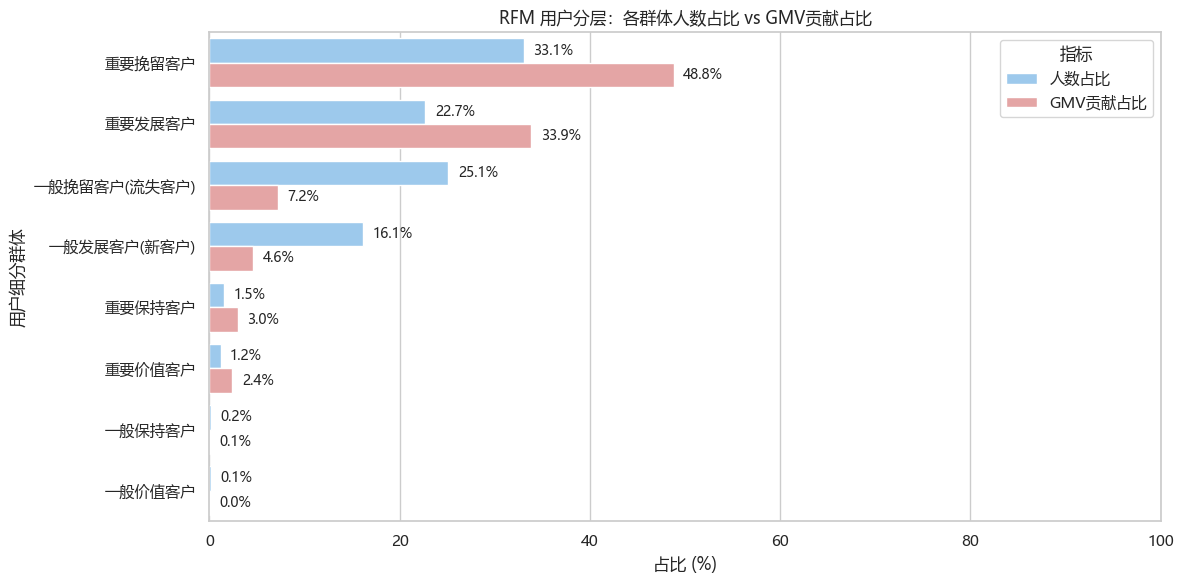

In [15]:
# ------------------- 用户分层可视化 ------------------------------

# 再次设置字体，防止失效
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  
plt.rcParams['axes.unicode_minus'] = False

# 准备数据
segment_summary = df_rfm_raw.groupby('segment').agg(
    user_count=('customer_unique_id', 'count'),
    total_gmv=('monetary', 'sum')
).reset_index()

# 计算占比
segment_summary['user_pct'] = segment_summary['user_count'] / segment_summary['user_count'].sum() * 100
segment_summary['gmv_pct'] = segment_summary['total_gmv'] / segment_summary['total_gmv'].sum() * 100
segment_summary = segment_summary.sort_values(by='gmv_pct', ascending=False)

# 绘图

plt.figure(figsize=(12, 6))

# 将数据整理为适合 seaborn 绘制的格式
plot_data = pd.melt(
    segment_summary, 
    id_vars=['segment'], 
    value_vars=['user_pct', 'gmv_pct'],
    var_name='指标类型', 
    value_name='占比(%)'
)
plot_data['指标类型'] = plot_data['指标类型'].map({'user_pct': '人数占比', 'gmv_pct': 'GMV贡献占比'})

# 绘制分组柱状图
ax = sns.barplot(
    x='占比(%)', 
    y='segment', 
    hue='指标类型', 
    data=plot_data, 
    palette=['#90caf9', '#ef9a9a'] # 蓝色代表人数，红色代表金额
)

# 在柱状图上标注具体数值
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 1, 
            p.get_y() + p.get_height()/2, 
            f'{width:.1f}%', 
            ha='left', 
            va='center', 
            fontsize=10, 
        )

plt.title('RFM 用户分层：各群体人数占比 vs GMV贡献占比')
plt.xlabel('占比 (%)')
plt.ylabel('用户细分群体')
plt.xlim(0, 100)
plt.legend(title='指标')
plt.tight_layout()
plt.show()


# 通过用户分层，可以发现客户群体中超过50%是重要挽留客户和重要发展客户，还有25%的流失客户，可见平台的客户流失非常严重
# 重要挽留顾客和重要发展顾客贡献了超过80%的营业额，说明平台的营收结构十分脆弱，缺乏稳定的销售点
# 以上两点说明，虽然数据上平台每月的的订单数和销售额呈现出递增趋势，但这更像是互联网红利下的虚假繁荣
# 平台需要抓住时代红利，加大对基础设施、用户需求方面的投入，实现对用户的深度绑定，以短期利益换取长远的未来

In [16]:
# ====================================== 深入探究：物流分析 ====================================

# ------------------- 准备数据 -----------------------

# 1、读取数据
logistics_expanded_sql = """
SELECT 
    o.order_id,
    o.order_status,
    c.customer_unique_id,
    c.customer_state,
    o.order_purchase_timestamp,
    o.order_delivered_carrier_date,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    oi.price,
    oi.freight_value,
    r.review_score
FROM orders o
INNER JOIN customers c ON o.customer_id = c.customer_id
INNER JOIN order_items oi ON o.order_id = oi.order_id
LEFT JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_delivered_carrier_date IS NOT NULL  -- 核心修改：只要发了货的都算
"""

df_logistics = pd.read_sql_query(logistics_expanded_sql, con)

# 处理重复值
df_logistics.drop_duplicates(inplace=True)

# 转换时间格式
date_cols = ['order_purchase_timestamp', 'order_delivered_carrier_date', 
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    df_logistics[col] = pd.to_datetime(df_logistics[col])

# 过滤 2016 年噪音
df_logistics = df_logistics[df_logistics['order_purchase_timestamp'].dt.year != 2016]

# 定义“今天”作为分析基准点（数据集中最后一笔订单时间）
today = df_logistics['order_purchase_timestamp'].max()

# ==============================================================================
# 2. 核心计算：兼容“已送达”与“在途/滞留”的算法
# ==============================================================================

# 2.1 商家处理时长（所有订单都可以算，因为都发货了）
df_logistics['seller_days'] = (df_logistics['order_delivered_carrier_date'] - df_logistics['order_purchase_timestamp']).dt.total_seconds() / 86400

# 2.2 物流运输时长（分类讨论）
# - 如果已送达：用 实际送达时间 - 发货时间
# - 如果在途中：用 今天 - 发货时间（代表已经漂流了多少天）
df_logistics['carrier_days'] = np.where(
    df_logistics['order_status'] == 'delivered',
    (df_logistics['order_delivered_customer_date'] - df_logistics['order_delivered_carrier_date']).dt.total_seconds() / 86400,
    (today - df_logistics['order_delivered_carrier_date']).dt.total_seconds() / 86400
)

# 2.3 总配送时长
df_logistics['total_delivery_days'] = df_logistics['seller_days'] + df_logistics['carrier_days']

# 2.4 承诺偏差天数与超期判定（SLA）
# - 如果已送达：实际送达 - 预计送达
# - 如果在途中：今天 - 预计送达
df_logistics['sla_delta'] = np.where(
    df_logistics['order_status'] == 'delivered',
    (df_logistics['order_delivered_customer_date'] - df_logistics['order_estimated_delivery_date']).dt.total_seconds() / 86400,
    (today - df_logistics['order_estimated_delivery_date']).dt.total_seconds() / 86400
)

# 判定是否超期（偏差 > 0 即为超期）
df_logistics['is_overdue'] = df_logistics['sla_delta'] > 0

# 运费率
df_logistics['freight_ratio'] = df_logistics['freight_value'] / df_logistics['price']

# ==============================================================================
# 3. 关联 RFM 用户分层数据
# ==============================================================================
df_merged = pd.merge(
    df_logistics, 
    df_rfm_raw[['customer_unique_id', 'segment']], 
    on='customer_unique_id', 
    how='inner'
)

print(f"【新数据集准备完毕】")
print(f"总样本量: {len(df_merged)}")
print(f"其中已送达(delivered)数量: {len(df_merged[df_merged['order_status']=='delivered'])}")
print(f"其中在途/滞留(shipped)数量: {len(df_merged[df_merged['order_status']=='shipped'])}")
print(f"其中发货后取消(canceled)数量: {len(df_merged[df_merged['order_status']=='canceled'])}")

【新数据集准备完毕】
总样本量: 99359
其中已送达(delivered)数量: 99291
其中在途/滞留(shipped)数量: 63
其中发货后取消(canceled)数量: 5


C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_16632\2029365711.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


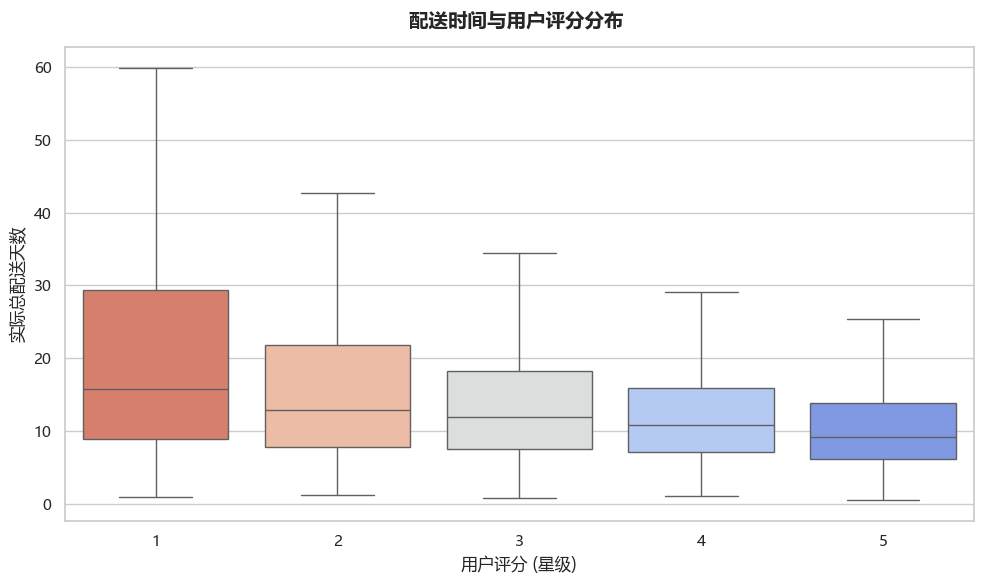

In [17]:
# -------------------- 配送时长与用户评分的关系 ----------------------

plt.figure(figsize=(10, 6))

# 绘制箱线图，限制 y 轴在 60 天以内以排除极端异常值，看得更清晰
sns.boxplot(
    x='review_score', 
    y='total_delivery_days', 
    data=df_merged, 
    palette='coolwarm_r',
    showfliers=False # 不显示异常值点，使箱体更美观
)

plt.title('配送时间与用户评分分布 ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('用户评分 (星级)', fontsize=12)
plt.ylabel('实际总配送天数', fontsize=12)
plt.tight_layout()
plt.show()


# 从下面的箱型图可以看出，1星评价订单的平均配送时间接近20天，5星评价订单的平均配送时间只有10天，二者相差巨大
# 可见，改善物流是提升服务品质的重要部分，恶劣的物流服务很可能对用户的消费意愿造成严重打击

C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_16632\791176228.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


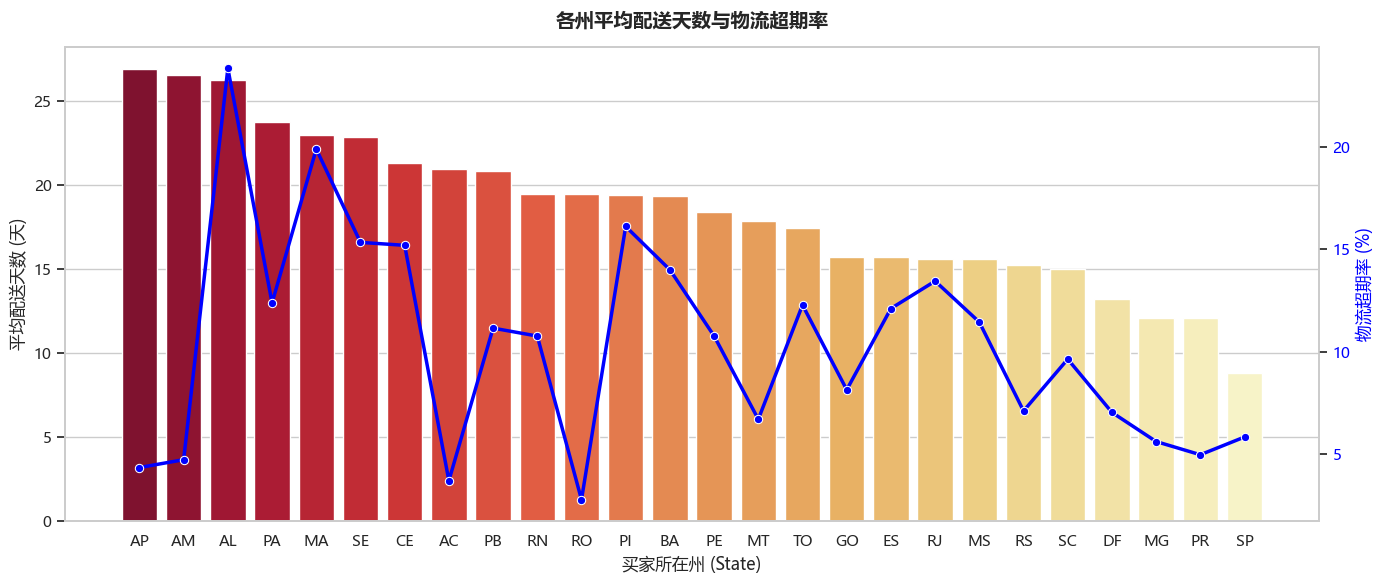

In [18]:
# 计算各州的平均配送天数和超期率
state_logistics = df_merged.groupby('customer_state').agg(
    avg_delivery=('total_delivery_days', 'mean'),
    overdue_rate=('is_overdue', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

# 过滤掉订单量极少的州（比如少于50单的），确保数据有代表性
state_logistics = state_logistics[state_logistics['order_count'] > 50]
state_logistics = state_logistics.sort_values(by='avg_delivery', ascending=False)

# 开始画图
fig, ax1 = plt.subplots(figsize=(14, 6))

# 1. 绘制柱状图（平均配送天数）
sns.barplot(
    x='customer_state', 
    y='avg_delivery', 
    data=state_logistics, 
    ax=ax1, 
    palette='YlOrRd_r'
)
ax1.set_title('各州平均配送天数与物流超期率', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('买家所在州 (State)', fontsize=12)
ax1.set_ylabel('平均配送天数 (天)', fontsize=12)

# 2. 绘制折线图（超期率）- 使用双 Y 轴
ax2 = ax1.twinx()
sns.lineplot(
    x='customer_state', 
    y=state_logistics['overdue_rate'] * 100, # 转为百分比
    data=state_logistics, 
    ax=ax2, 
    color='blue', 
    marker='o', 
    linewidth=2.5,
    sort=False
)
ax2.set_ylabel('物流超期率 (%)', fontsize=12, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.grid(False) # 关闭折线图的网格线，避免重叠

plt.tight_layout()
plt.show()


# 受巴西疆域辽阔的影响，加上跨州交易占据了60%的订单，各州的平均配送天数普遍较高，AP、AM等比较偏远的州的平均配送天数甚至逼近一个月
# 而且，大多数州的超期率都在10%以上，可见物流质量比较低下，其中AL的超期率甚至超过了20%
# 针对这类情况，简单的增效无法从根本上改变受限于地理的物流困境，建议开发本地仓储模式，将分散全国各地的货物运输到离消费者较近的地区，进行集中处理

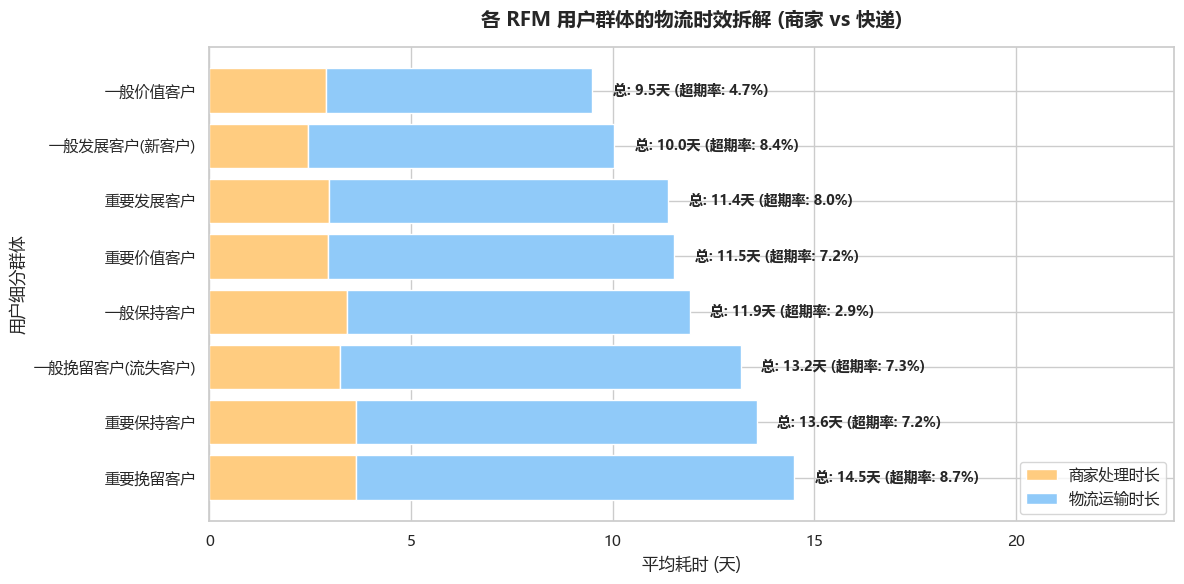

In [19]:
# 计算每个 RFM 群体的物流表现
segment_logistics = df_merged.groupby('segment').agg(
    avg_seller_days=('seller_days', 'mean'),
    avg_carrier_days=('carrier_days', 'mean'),
    avg_total_days=('total_delivery_days', 'mean'),
    overdue_rate=('is_overdue', 'mean')
).reset_index().sort_values(by='avg_total_days', ascending=False)

# 绘制堆叠条形图（商家处理时长 + 物流运输时长）
plt.figure(figsize=(12, 6))

# 准备堆叠图数据
r_labels = segment_logistics['segment'].tolist()
seller_means = segment_logistics['avg_seller_days'].tolist()
carrier_means = segment_logistics['avg_carrier_days'].tolist()

# 画商家处理时长
bars1 = plt.barh(r_labels, seller_means, label='商家处理时长', color='#ffcc80')
# 画物流运输时长（叠在商家处理时长后面）
bars2 = plt.barh(r_labels, carrier_means, left=seller_means, label='物流运输时长', color='#90caf9')

# 标注总天数和超期率
for i, row in enumerate(segment_logistics.itertuples()):
    total_days = row.avg_total_days
    overdue_pct = row.overdue_rate * 100
    plt.text(
        total_days + 0.5, 
        i, 
        f"总: {total_days:.1f}天 (超期率: {overdue_pct:.1f}%)", 
        va='center', 
        fontweight='bold', 
        fontsize=10
    )

plt.title('各 RFM 用户群体的物流时效拆解 (商家 vs 快递)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('平均耗时 (天)', fontsize=12)
plt.ylabel('用户细分群体', fontsize=12)
plt.legend(loc='lower right')
plt.xlim(0, max(seller_means + carrier_means) * 2.2) # 留出右侧标注空间
plt.tight_layout()
plt.show()

# 各RFM用户群体中，重要挽留顾客是平台最重要的GMV贡献群体，但是物流时效却是所有群体里最低的，如果不能推出相关措施，很可能会加剧顾客流失
# 商家处理时长也是导致超期率的一大因素，商家处理时长普遍在2-4天左右，应将其纳入改善物流的计划内

In [20]:
# =============================== 深入探究：用户支付情况 ==========================

# -------------- 数据准备 ----------------

# 提取支付与订单状态数据
payment_sql = """
SELECT 
    o.order_id,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_approved_at,
    p.payment_type,
    p.payment_installments,
    p.payment_value
FROM orders o
INNER JOIN order_payments p ON o.order_id = p.order_id
"""

df_payments = pd.read_sql_query(payment_sql, con)

# 处理重复值
df_payments.drop_duplicates(inplace=True)

# 转换时间格式
df_payments['order_purchase_timestamp'] = pd.to_datetime(df_payments['order_purchase_timestamp'])
df_payments['order_approved_at'] = pd.to_datetime(df_payments['order_approved_at'])

# 过滤 2016 年噪音数据
df_payments = df_payments[df_payments['order_purchase_timestamp'].dt.year != 2016]

# 计算 Boleto 支付确认延迟（小时）
# Boleto 需要银行清算，通常比信用卡慢
df_payments['pay_delay_hours'] = (df_payments['order_approved_at'] - df_payments['order_purchase_timestamp']).dt.total_seconds() / 3600

print("支付数据准备完毕！样本量：", len(df_payments))

支付数据准备完毕！样本量： 102927


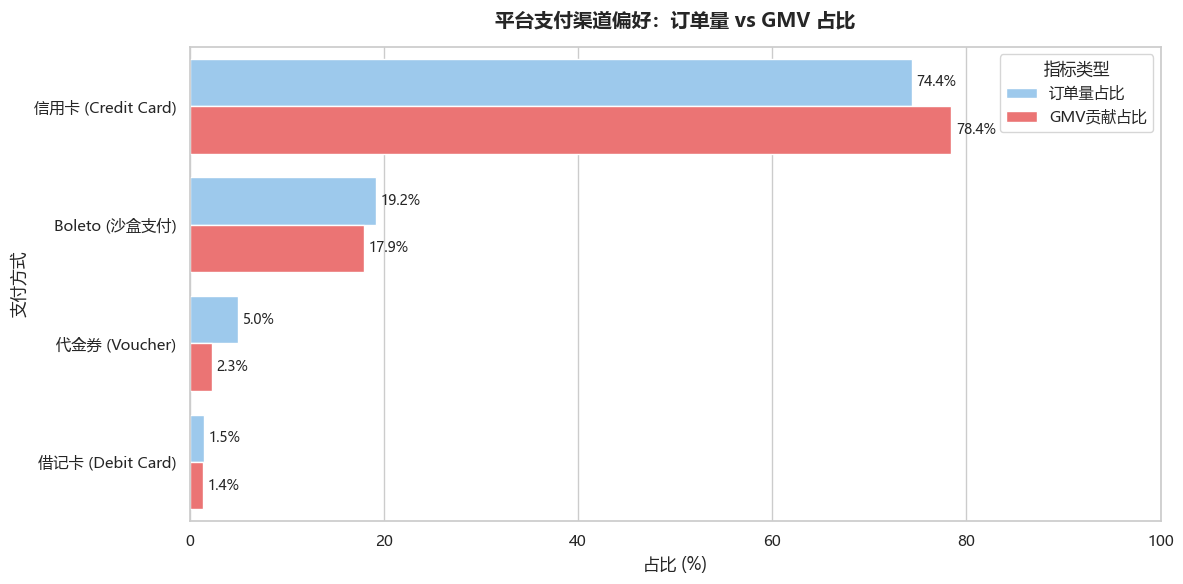

In [21]:
# --------------------------- 支付结构分析 ----------------------

# 计算支付方式占比
pay_summary = df_payments.groupby('payment_type').agg(
    order_count=('order_id', 'count'),
    total_gmv=('payment_value', 'sum')
).reset_index()

# 过滤掉极少数的 'not_defined'
pay_summary = pay_summary[pay_summary['payment_type'] != 'not_defined']

# 计算百分比
pay_summary['order_pct'] = pay_summary['order_count'] / pay_summary['order_count'].sum() * 100
pay_summary['gmv_pct'] = pay_summary['total_gmv'] / pay_summary['total_gmv'].sum() * 100
pay_summary = pay_summary.sort_values(by='gmv_pct', ascending=False)

# 映射中文名称
pay_map = {
    'credit_card': '信用卡 (Credit Card)',
    'boleto': 'Boleto (沙盒支付)',
    'voucher': '代金券 (Voucher)',
    'debit_card': '借记卡 (Debit Card)'
}
pay_summary['payment_type_zh'] = pay_summary['payment_type'].map(pay_map)

# 绘图
plt.figure(figsize=(12, 6))
plot_data = pd.melt(
    pay_summary, 
    id_vars=['payment_type_zh'], 
    value_vars=['order_pct', 'gmv_pct'],
    var_name='指标类型', 
    value_name='占比(%)'
)
plot_data['指标类型'] = plot_data['指标类型'].map({'order_pct': '订单量占比', 'gmv_pct': 'GMV贡献占比'})

ax = sns.barplot(
    x='占比(%)', 
    y='payment_type_zh', 
    hue='指标类型', 
    data=plot_data, 
    palette=['#90caf9', "#FF6060"]
)

# 标注数值
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 0.5, 
            p.get_y() + p.get_height()/2, 
            f'{width:.1f}%', 
            ha='left', 
            va='center', 
            fontsize=10
        )

plt.title('平台支付渠道偏好：订单量 vs GMV 占比', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('占比 (%)')
plt.ylabel('支付方式')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

# 从支付结构上看，信用卡是绝对的霸主，贡献了超过70%的订单量和交易额
# 但Boleto作为一种线下打印凭条，去商店或银行付款的传统方式，仍占据了近20%的市场份额
# 在互联网时代，巴西电商的生态仍带有明显的传统色彩，体现出新工具和新方式的普及过程中面对的环境阻力以及信任问题

C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_16632\2497551482.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


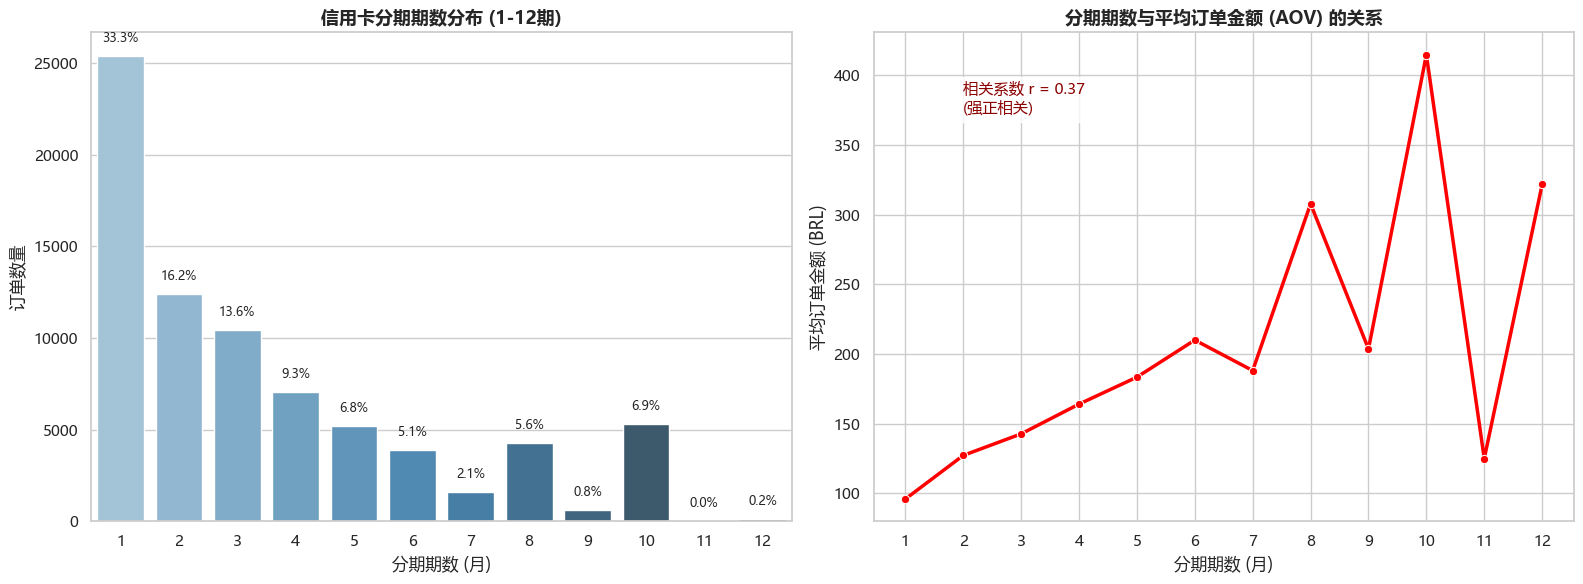

In [22]:
# ----------------------- 分期期数与客单价的关系 -------------------------------

# 过滤出信用卡数据
df_credit = df_payments[df_payments['payment_type'] == 'credit_card'].copy()

# 限制分期数在 1-12 期（排除极少数异常超长分期）
df_credit = df_credit[(df_credit['payment_installments'] >= 1) & (df_credit['payment_installments'] <= 12)]

# 计算各分期的平均订单金额
install_aov = df_credit.groupby('payment_installments')['payment_value'].mean().reset_index()

# 开始画双子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. 左图：分期期数分布
sns.countplot(
    x='payment_installments', 
    data=df_credit, 
    ax=ax1, 
    palette='Blues_d'
)
ax1.set_title('信用卡分期期数分布 (1-12期)', fontsize=13, fontweight='bold')
ax1.set_xlabel('分期期数 (月)')
ax1.set_ylabel('订单数量')

# 在柱状图上标百分比
total_credit_orders = len(df_credit)
for p in ax1.patches:
    height = p.get_height()
    pct = (height / total_credit_orders) * 100
    ax1.text(
        p.get_x() + p.get_width()/2, 
        height + total_credit_orders*0.01, 
        f'{pct:.1f}%', 
        ha='center', 
        fontsize=9
    )

# 2. 右图：分期期数 vs 平均订单金额 (AOV)
sns.lineplot(
    x='payment_installments', 
    y='payment_value', 
    data=install_aov, 
    ax=ax2, 
    marker='o', 
    color='red', 
    linewidth=2.5
)
ax2.set_title('分期期数与平均订单金额 (AOV) 的关系', fontsize=13, fontweight='bold')
ax2.set_xlabel('分期期数 (月)')
ax2.set_ylabel('平均订单金额 (BRL)')
ax2.set_xticks(range(1, 13))

# 计算相关系数
corr = df_credit['payment_installments'].corr(df_credit['payment_value'])
ax2.text(2, install_aov['payment_value'].max() * 0.9, f'相关系数 r = {corr:.2f}\n(强正相关)', 
         bbox=dict(facecolor='white', alpha=0.8), fontsize=11, color='darkred')

plt.tight_layout()
plt.show()


# 分期支付在巴西电商交易中非常普遍，只有三分之一的客户选择一期支付，并且分期期数与订单金额存在强正相关
# 说明就当下的经济环境下，分期支付将是平台的主流交易方式，有利于增加了客户的消费能力，增加了GMV和客单价
# 但是如此庞大的账单也具有极大的风险，大量的资金占用很考验平台的资金周转能力，以及需要科学健康的管理体系来避免坏账爆发的问题

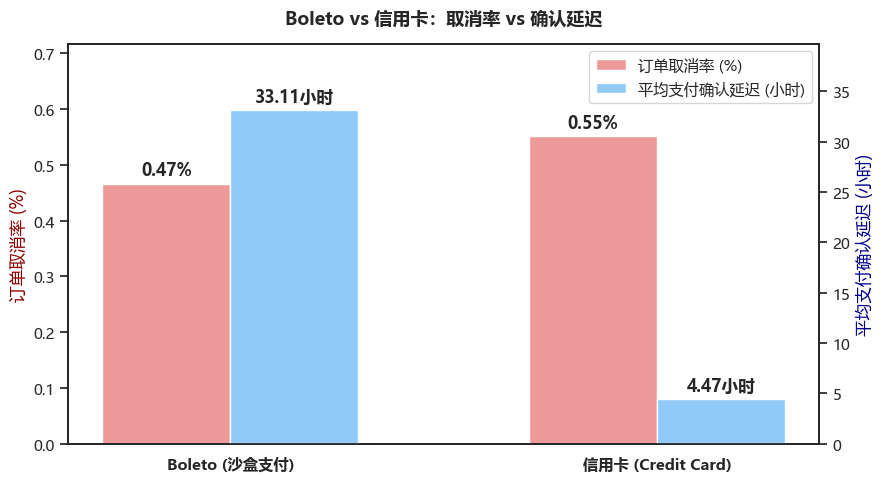

In [ ]:
# Boleto与信用卡对比

# 计算取消率(%)和平均延迟
summary = df_payments[df_payments['payment_type'].isin(['credit_card', 'boleto'])].groupby('payment_type').agg(
    cancel_rate=('order_status', lambda x: (x == 'canceled').mean() * 100),
    avg_delay=('pay_delay_hours', 'mean')
).rename(index={'credit_card': '信用卡 (Credit Card)', 'boleto': 'Boleto (沙盒支付)'})

# ==============================================================================
# 2. 极简双 Y 轴画图
# ==============================================================================
sns.set_theme(style="white", rc={'font.sans-serif': ['Microsoft YaHei', 'SimHei'], 'axes.unicode_minus': False})
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

x = np.arange(len(summary))
width = 0.3

# 绘制双轴柱状图
rects1 = ax1.bar(x - width/2, summary['cancel_rate'], width, label='订单取消率 (%)', color='#ef9a9a')
rects2 = ax2.bar(x + width/2, summary['avg_delay'], width, label='平均支付确认延迟 (小时)', color='#90caf9')

ax1.bar_label(rects1, fmt='%.2f%%', padding=3, weight='bold')
ax2.bar_label(rects2, fmt='%.2f小时', padding=3, weight='bold')

# 轴与标签设置
ax1.set_xticks(x)
ax1.set_xticklabels(summary.index, fontsize=11, fontweight='bold')
ax1.set_ylabel('订单取消率 (%)', color='darkred')
ax2.set_ylabel('平均支付确认延迟 (小时)', color='darkblue')
ax1.set_ylim(0, summary['cancel_rate'].max() * 1.3)
ax2.set_ylim(0, summary['avg_delay'].max() * 1.2)

# 合并图例
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')

plt.title('Boleto vs 信用卡：取消率 vs 确认延迟', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


# 由于需要用户线下去银行付款，Boleto的支付延迟确认时间远高于信用卡支付，但令人意想不到的是，Boleto的取消率却低于信用卡支付，仅有0.47%
# 作为一个综合性的电商平台，如此低的取消率除了能说明平台的运营成绩，还可能存在某些隐形问题，比如前面提到的极低的复购率，需要一定的警惕

In [25]:
# =============================== 商品与卖家生态 ============================

# --------------- 数据准备 ---------------

# 1. 提取品类与销售数据

con = sqlite3.connect('olist.db')

category_sql = """
SELECT 
    t.product_category_name_english AS category,
    oi.order_id,
    oi.price
FROM order_items oi
INNER JOIN products p ON oi.product_id = p.product_id
LEFT JOIN category_translation t ON p.product_category_name = t.product_category_name
"""
df_cat_raw = pd.read_sql_query(category_sql, con)

# 2. 提取卖家服务质量数据
seller_sql = """
SELECT 
    oi.seller_id,
    oi.order_id,
    oi.price,
    o.order_purchase_timestamp,
    o.order_delivered_carrier_date,
    r.review_score
FROM order_items oi
INNER JOIN orders o ON oi.order_id = o.order_id
LEFT JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_delivered_carrier_date IS NOT NULL
"""
df_sel_raw = pd.read_sql_query(seller_sql, con)

# 转换时间格式
df_sel_raw['order_purchase_timestamp'] = pd.to_datetime(df_sel_raw['order_purchase_timestamp'])
df_sel_raw['order_delivered_carrier_date'] = pd.to_datetime(df_sel_raw['order_delivered_carrier_date'])

# 处理重复值
df_cat_raw.drop_duplicates(inplace=True)
df_cat_raw.drop_duplicates(inplace=True)

# 计算商家处理时长（天）
df_sel_raw['handling_days'] = (df_sel_raw['order_delivered_carrier_date'] - df_sel_raw['order_purchase_timestamp']).dt.total_seconds() / 86400

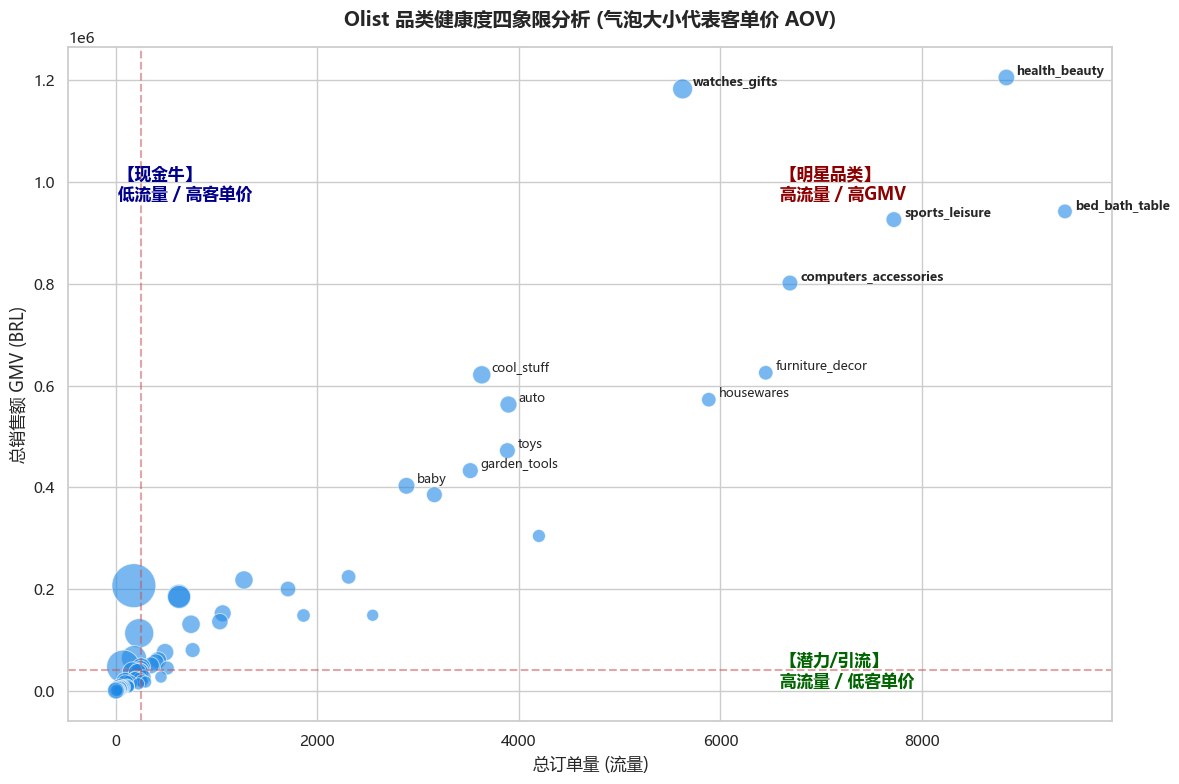

In [26]:
# ------------------ 品类分析 --------------------

# 聚合品类数据
df_cat = df_cat_raw.groupby('category').agg(
    order_volume=('order_id', 'nunique'),
    gmv=('price', 'sum')
).reset_index()
df_cat['aov'] = df_cat['gmv'] / df_cat['order_volume']

# 过滤掉无名品类
df_cat = df_cat.dropna().sort_values(by='gmv', ascending=False)

# 绘图设置
sns.set_theme(style="whitegrid", rc={'font.sans-serif': ['Microsoft YaHei', 'SimHei'], 'axes.unicode_minus': False})
plt.figure(figsize=(12, 8))

# 绘制散点图（气泡大小代表 AOV）
scatter = sns.scatterplot(
    x='order_volume', 
    y='gmv', 
    size='aov', 
    sizes=(50, 1000), 
    data=df_cat, 
    alpha=0.6, 
    color='#1e88e5',
    legend=False
)

# 划分象限（使用中位数划分，避免极值干扰）
x_median = df_cat['order_volume'].median()
y_median = df_cat['gmv'].median()

plt.axvline(x=x_median, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=y_median, color='r', linestyle='--', alpha=0.5)

# 标注 Top 10 热门品类名称
for i in range(min(12, len(df_cat))):
    row = df_cat.iloc[i]
    plt.text(
        row['order_volume'] + 100, 
        row['gmv'] + 5000, 
        row['category'], 
        fontsize=9, 
        weight='bold' if i < 5 else 'normal'
    )

# 象限文字标注
plt.text(df_cat['order_volume'].max()*0.7, df_cat['gmv'].max()*0.8, '【明星品类】\n高流量 / 高GMV', color='darkred', fontsize=12, weight='bold')
plt.text(x_median*0.1, df_cat['gmv'].max()*0.8, '【现金牛】\n低流量 / 高客单价', color='darkblue', fontsize=12, weight='bold')
plt.text(df_cat['order_volume'].max()*0.7, y_median*0.2, '【潜力/引流】\n高流量 / 低客单价', color='darkgreen', fontsize=12, weight='bold')

plt.title('Olist 品类健康度四象限分析 (气泡大小代表客单价 AOV)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('总订单量 (流量)', fontsize=12)
plt.ylabel('总销售额 GMV (BRL)', fontsize=12)
plt.tight_layout()
plt.show()

# 从图可以看出，平台旗下有watch_gifts(手表礼品)、health_beauty(美妆)、computers_accessories(电脑配件)等多种主力产品，分散在多个领域里
# 平台可以进一步增加对现金牛类产品和卡在图中间的潜力产品的营销，削减一些边缘产品，促进产品销售的健康发展
# 针对主力产品的分散性，可能会面临来自垂直平台或具有招牌产品的其他平台的竞争压力
# 不能简单地摆上各种产品，作为综合性平台的同时，可以针对性深耕某些领域，增加消费者的信任感

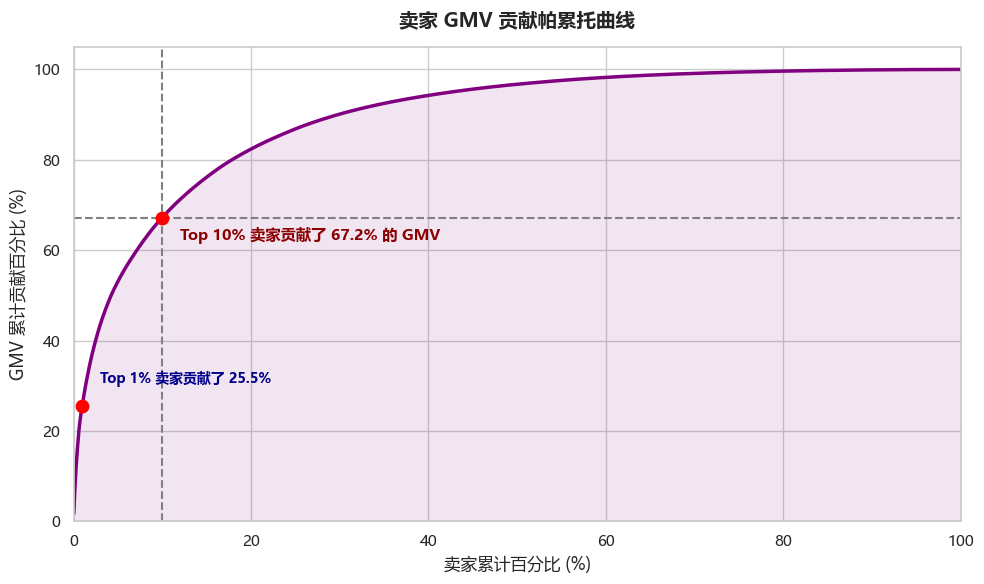

In [27]:
# ------------------------------- 卖家集中度分析 -------------------------

# 聚合卖家销售额
df_seller_sales = df_sel_raw.groupby('seller_id')['price'].sum().reset_index().sort_values(by='price', ascending=False)
df_seller_sales['cum_gmv'] = df_seller_sales['price'].cumsum()
df_seller_sales['cum_gmv_pct'] = (df_seller_sales['cum_gmv'] / df_seller_sales['price'].sum()) * 100

# 计算卖家累计百分比
df_seller_sales['seller_rank_pct'] = (np.arange(len(df_seller_sales)) + 1) / len(df_seller_sales) * 100

# 提取关键节点数据
top_1_pct = df_seller_sales[df_seller_sales['seller_rank_pct'] <= 1]['cum_gmv_pct'].max()
top_10_pct = df_seller_sales[df_seller_sales['seller_rank_pct'] <= 10]['cum_gmv_pct'].max()

# 绘图
plt.figure(figsize=(10, 6))
plt.plot(df_seller_sales['seller_rank_pct'], df_seller_sales['cum_gmv_pct'], color='purple', linewidth=2.5, label='GMV 累计贡献率')
plt.fill_between(df_seller_sales['seller_rank_pct'], df_seller_sales['cum_gmv_pct'], color='purple', alpha=0.1)

# 标注关键点
plt.scatter([1, 10], [top_1_pct, top_10_pct], color='red', s=80, zorder=5)
plt.axvline(x=10, color='grey', linestyle='--')
plt.axhline(y=top_10_pct, color='grey', linestyle='--')

plt.text(12, top_10_pct - 5, f"Top 10% 卖家贡献了 {top_10_pct:.1f}% 的 GMV", color='darkred', weight='bold', fontsize=11)
plt.text(3, top_1_pct + 5, f"Top 1% 卖家贡献了 {top_1_pct:.1f}%", color='darkblue', weight='bold', fontsize=10)

plt.title('卖家 GMV 贡献帕累托曲线', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('卖家累计百分比 (%)', fontsize=12)
plt.ylabel('GMV 累计贡献百分比 (%)', fontsize=12)
plt.xlim(0, 100)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()


# Olist平台也具有典型的八二法则，前10%的商家贡献了近70%的GMV

C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_16632\2497737848.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='seller_group', y='avg_handling', data=group_comparison, ax=ax1, palette=['#ef9a9a', '#90caf9'])
C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_16632\2497737848.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='seller_group', y='avg_rating', data=group_comparison, ax=ax2, palette=['#ef9a9a', '#90caf9'])


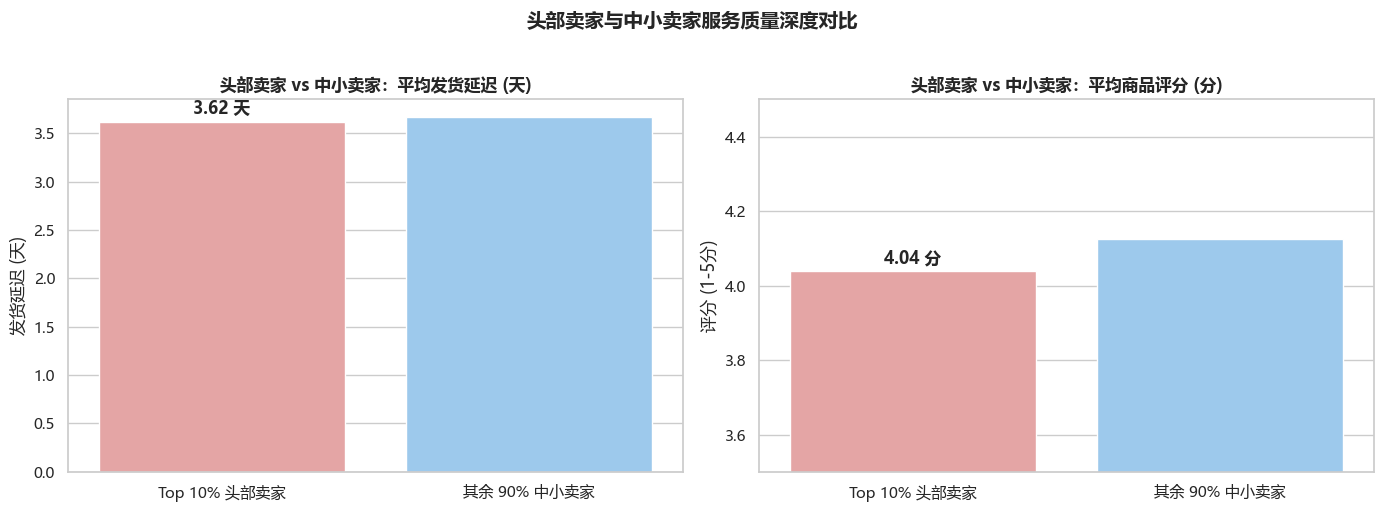

In [28]:
# -------------------- 卖家服务质量分析 --------------------

# 1. 计算每个卖家的销售额、平均评分、平均发货延迟
df_seller_metrics = df_sel_raw.groupby('seller_id').agg(
    total_sales=('price', 'sum'),
    avg_rating=('review_score', 'mean'),
    avg_handling=('handling_days', 'mean')
).reset_index()

# 2. 划分头部卖家（Top 10%）与普通卖家
threshold = df_seller_metrics['total_sales'].quantile(0.90)
df_seller_metrics['seller_group'] = np.where(df_seller_metrics['total_sales'] >= threshold, 'Top 10% 头部卖家', '其余 90% 中小卖家')

# 3. 聚合对比
group_comparison = df_seller_metrics.groupby('seller_group').agg(
    avg_rating=('avg_rating', 'mean'),
    avg_handling=('avg_handling', 'mean')
).reset_index()

# 4. 绘制对比图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：发货延迟对比
sns.barplot(x='seller_group', y='avg_handling', data=group_comparison, ax=ax1, palette=['#ef9a9a', '#90caf9'])
ax1.set_title('头部卖家 vs 中小卖家：平均发货延迟 (天)', fontsize=12, fontweight='bold')
ax1.set_ylabel('发货延迟 (天)')
ax1.set_xlabel('')
ax1.bar_label(ax1.containers[0], fmt='%.2f 天', padding=3, weight='bold')

# 右图：评分对比
sns.barplot(x='seller_group', y='avg_rating', data=group_comparison, ax=ax2, palette=['#ef9a9a', '#90caf9'])
ax2.set_title('头部卖家 vs 中小卖家：平均商品评分 (分)', fontsize=12, fontweight='bold')
ax2.set_ylabel('评分 (1-5分)')
ax2.set_xlabel('')
ax2.set_ylim(3.5, 4.5)  # 聚焦评分差异
ax2.bar_label(ax2.containers[0], fmt='%.2f 分', padding=3, weight='bold')

plt.suptitle('头部卖家与中小卖家服务质量深度对比', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# 由图可知，头部卖家和中小卖家的平均发货延迟相差无几，可见物流问题是普遍存在
# 商品评分与商品质量、卖家服务、物流运输等多方面有关，是对商家综合评估的参考之一，值得注意的是头部卖家的平均商品评分低于中小卖家
# 头部卖家是平台支柱，平台需要加强对头部卖家的约束，帮助和督促头部卖家建立起更好的服务体系

In [ ]:
# ======================= 导出整合的数据，制作Tablau看板 ========================

# 1. 导出【大盘、地域与用户分层表】（整合：基础1、2、3 + 深入：RFM、支付行为）
# 将 rfm 分层结果合并回 df_four
df_sales_rfm = pd.merge(
    df_four, 
    df_rfm_raw[['customer_unique_id', 'segment']], 
    on='customer_unique_id', 
    how='left'
)
# 关联支付信息（取每个订单的主要支付方式和分期）
df_pay_temp = df_payments.groupby('order_id').agg({
    'payment_type': 'first',
    'payment_installments': 'max',
    'payment_value': 'sum'
}).reset_index()

df_tableau_sales = pd.merge(df_sales_rfm, df_pay_temp, on='order_id', how='left')
df_tableau_sales.to_csv('tableau_sales_rfm.csv', index=False)

# 2. 导出【物流时效与评分表】（整合：基础5 + 深入：物流分析）
df_merged.to_csv('tableau_logistics.csv', index=False)

# 3. 导出【卖家与品类生态表】（整合：基础3 + 深入：卖家生态）
# 包含卖家销售额、平均评分、平均发货延迟
df_seller_metrics.to_csv('tableau_seller_ecosystem.csv', index=False)

✅ 成功导出：tableau_sales_rfm.csv (用于大盘、地域、RFM和支付分析)
✅ 成功导出：tableau_logistics.csv (用于物流时效与客诉分析)
✅ 成功导出：tableau_seller_ecosystem.csv (用于卖家与品类四象限分析)
